## Problem 3: GPS User Segment [20 points + 2 bonus]

**Goal of this problem**: Students will learn about the GPS user segment and the key geometric interpretation of GPS navigation.

Consider a system of 2D buzzers in a 2D coordinate plane, each equipped with an atomic clock, where all buzzer clocks are perfectly synchronized within the system.

Each buzzer broadcasts:
1. a buzzing sound,
2. the buzzing sound's corresponding precise time of transmission $t^{(k)}$, and
3. the buzzer's number $k$.

Additionally consider that you have a receiver, that is equipped with a local clock that records the time of reception $t_u^{(k)}$ for each buzzing sound.
However, the receiver clock has an unknown clock bias $t_b$, which means the true reception time for the sound from buzzer $k$ is $t_u^{(k)} - t_b$.

For this problem, we will build a 2D trilateration system based on this system of buzzers.
Assume that the speed of sound is $c_{\text{sound}} = 340$ m/s.
Assume your position is stationary, and the receiver clock bias is constant for all buzzer sounds you receive.

**Instruction for Plots**: For your plot, please make sure the following are satisfied.
* Ensure that $x$ is along the horizontal axis and $y$ is along the vertical axis.
* Ensure your axes are labeled and the **aspect ratio is equal**.
* **Include grid lines and a legend** that distinguishes the position of buzzers from the possible positions.
* **Please use the same plot bounds for all parts of this problem**: [-3000, 3000] for $x$ and [-3000, 3000] for $y$.

*It may be helpful to leverage the navigation equations we learned in Lecture 3 for this problem.*


### 3.1 [2 points]
You know that Buzzer 1 is located at (500 m, 1000 m) in the global frame of reference.

Using symbols $t^{(1)}$, $t_b$, and $t_u^{(1)}$, write the equation satisfied by your true position $(x,y)$, when you receive the measurement from Buzzer 1.

***ANSWER***

$$\vec{x}^{(1)}-\vec{x} = \begin{pmatrix}x \\ y\end{pmatrix} - \begin{pmatrix}500 \\ 1000\end{pmatrix} = c ( t_u^{(1)} - t_b - t^{(1)})$$

$$\begin{pmatrix}x \\ y\end{pmatrix} = c ( t_u^{(1)} - t_b - t^{(1)}) + \begin{pmatrix}500 \\ 1000\end{pmatrix}$$

### 3.2 [3 points]
Assume $t^{(1)}$ = 0.5 s, $t_b$ = +0.1 s, and $t_u^{(1)}$ = 4.1 s.

Plot the geometry in the $xy$ plane that satisfies your equation from part 3.1, along with the location of Buzzer 1.

*Hint:* You might find it easier to graph the geometry if you first create the array of 100 evenly spaced (angle) points going from $0$ to $2\pi$ radians.

***ANSWER***

In [71]:
import numpy as np
import plotly.graph_objs as px_go
from dataclasses import dataclass
import matplotlib.pyplot as plt

In [72]:
c_speed_sound = 340 # m/s
t_1 = 0.5 # s
t_b = 0.1 # s
t_u_1 = 4.1 # s

In [73]:
@dataclass
class Buzzer:
  x: float
  y: float
  dist_lower: float
  dist_upper: float

  inner_x_points: np.array
  inner_y_points: np.array
  outer_x_points: np.array
  outer_y_points: np.array

In [74]:
def get_buzzer(buzzer_x, buzzer_y, t_k, t_b, t_u_k):

  dist_lower = c_speed_sound * (t_u_k - t_b - t_k)
  dist_upper = c_speed_sound * (t_u_k + t_b - t_k)

  circle_points = np.linspace(0, 2*np.pi, 1000)

  inner_x_points = np.cos(circle_points) * dist_lower + buzzer_x
  inner_y_points = np.sin(circle_points) * dist_lower + buzzer_y
  outer_x_points = np.cos(circle_points) * dist_upper + buzzer_x
  outer_y_points = np.sin(circle_points) * dist_upper + buzzer_y

  return Buzzer(
      x=buzzer_x,
      y=buzzer_y,
      dist_lower=dist_lower,
      dist_upper=dist_upper,
      inner_x_points=inner_x_points,
      inner_y_points=inner_y_points,
      outer_x_points=outer_x_points,
      outer_y_points=outer_y_points)


In [75]:
def plot_buzzers(buzzers: list[Buzzer], plot_title: str, range_type = "both", use_plotly = False):
  plot_objects = []

  if isinstance(buzzers, Buzzer):
    buzzers = [buzzers]

  if use_plotly:
    for i, buzzer in enumerate(buzzers):
      plot_objects += [
        px_go.Scatter(
          name=f'Buzzer {i}',
          x=[buzzer.x],
          y=[buzzer.y],
          mode='markers',
          marker=dict(color='red', size=10),
          showlegend=True
        ),
        px_go.Scatter(
            # name=f'Buzzer {i} Inner Estimate',
            x=buzzer.inner_x_points,
            y=buzzer.inner_y_points,
            mode='markers',
            marker=dict(color='red', size=2),
            showlegend=True
        ),
          px_go.Scatter(
            # name=f'Buzzer {i} Outer Estimate',
            x=buzzer.outer_x_points,
            y=buzzer.outer_y_points,
            mode='markers',
            marker=dict(color='blue', size=2),
            showlegend=True
        )
      ]

    fig = px_go.Figure(plot_objects)
    fig.update_layout(
      xaxis_title='x (m)',
      yaxis_title='y (m)',
      xaxis_range=[-3000, 3000],
      yaxis_range=[-3000, 3000],
      title=plot_title,
      hovermode="x"
    )
    fig.show()

  else:



    for i, buzzer in enumerate(buzzers):
      plt.scatter(buzzer.x, buzzer.y, label=f"Buzzer {i}")
      if range_type in ["both", "inner"]:
        plt.plot(buzzer.inner_x_points, buzzer.inner_y_points, 'r')
      if range_type in ["both", "outer"]:
        plt.plot(buzzer.outer_x_points, buzzer.outer_y_points, 'b')

    plt.legend()
    plt.title(plot_title)
    plt.xlim(-3000, 3000)
    plt.ylim(-3000, 3000)
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.grid(True)
    plt.show()



In [76]:
buzzer_1 = get_buzzer(500, 1000, t_1, t_b, t_u_1)

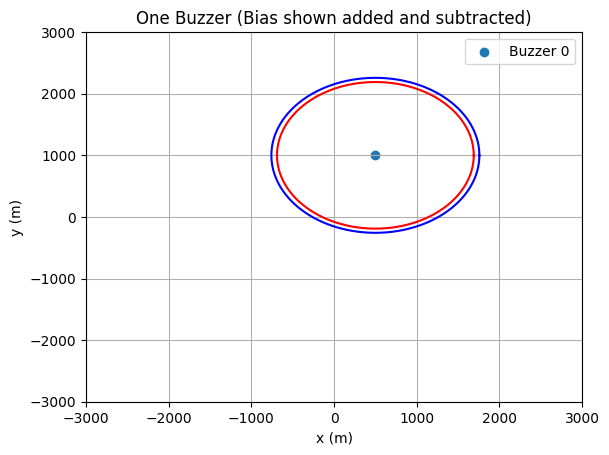

In [77]:
plot_buzzers(buzzer_1, "One Buzzer (Bias shown added and subtracted)")

### 3.3 [2 points]
In addition to Buzzer 1, your receiver also obtains a sound from Buzzer 2, which is located at (-1000 m, 0 m).

Using symbols $t^{(1)}$, $t^{(2)}$, $t_b$, $t_u^{(1)}$, and $t_u^{(2)}$, write the two equations satisfied by your true position (x,y).

***ANSWER***

$$\begin{pmatrix}x \\ y\end{pmatrix} = c ( t_u^{(1)} - t_b - t^{(1)}) + \begin{pmatrix}500 \\ 1000\end{pmatrix}$$

$$\begin{pmatrix}x \\ y\end{pmatrix} = c ( t_u^{(2)} - t_b - t^{(2)}) + \begin{pmatrix}-1000 \\ 0\end{pmatrix}$$

### 3.4 [2 points]
Assume $t^{(1)}$ = 0.5s, $t^{(2)}$ =1.5 s, $t_b$ = +0.1 s, $t_u^{(1)}$ = 4.1 s, and $t_u^{(2)}$ = 4.8 s.

Plot the two geometries that satisfy each equation, along with the location of the 2 buzzers.

From the plot, how many possible locations exist as the user position?

**You do not have to compute the positions**.

***ANSWER***

In [78]:
t_2 = 1.5 # s
t_u_2 = 4.8 # s

In [79]:
buzzer_2 = get_buzzer(-1000, 0, t_2, t_b, t_u_2)

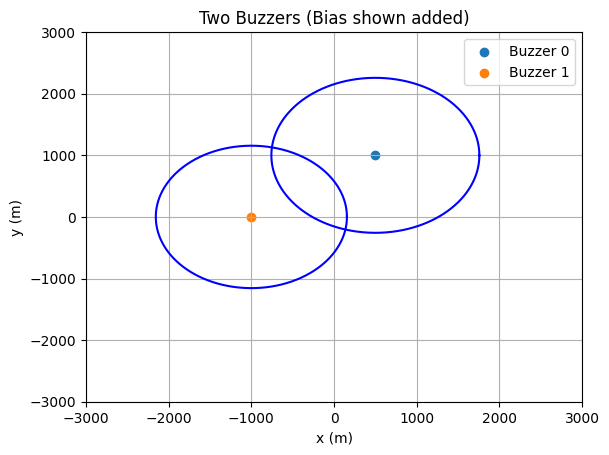

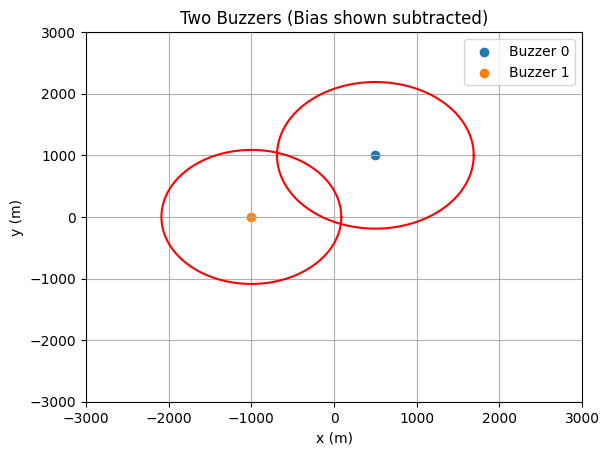

In [80]:
plot_buzzers([buzzer_1, buzzer_2], "Two Buzzers (Bias shown added)", range_type="outer")
plot_buzzers([buzzer_1, buzzer_2], "Two Buzzers (Bias shown subtracted)", range_type="inner")

### 3.5 [2 points]
In addition to Buzzer 1 and 2, your receiver also obtains a sound from Buzzer 3, which is located at (+1000 m, -1000 m). Using symbols $t^{(1)}$, $t^{(2)}$, $t^{(3)}$, $t_b$, $t_u^{|(1)}$, $t_u^{(2)}$, and $t_u^{(3)}$, write the three equations satisfied by your true position $(x,y)$.

***ANSWER***

$$\begin{pmatrix}x \\ y\end{pmatrix} = c ( t_u^{(1)} - t_b - t^{(1)}) + \begin{pmatrix}500 \\ 1000\end{pmatrix}$$

$$\begin{pmatrix}x \\ y\end{pmatrix} = c ( t_u^{(2)} - t_b - t^{(2)}) + \begin{pmatrix}-1000 \\ 0\end{pmatrix}$$

$$\begin{pmatrix}x \\ y\end{pmatrix} = c ( t_u^{(3)} - t_b - t^{(3)}) + \begin{pmatrix}-1000 \\ 1000\end{pmatrix}$$

### 3.6 [2 points]
Assume $t^{(1)}$ =0.5 s, $t^{(2)}$ =1.5 s, $t^{(3)}$ =0.0 s, $t_b$ = +0.1 s, $t_u^{(1)}$ = 4.1 s, $t_u^{(2)}$ = 4.8 s, and $t_u^{(3)}$ = 5.2 s. Plot the three geometries that satisfy each equation, along with the location of the 3 buzzers. Are there any locations that satisfies the three equations simultaneously?

***ANSWER***

In [81]:
t_3 = 0 # s
t_u_3 = 5.2 # s

In [82]:
buzzer_3 = get_buzzer(1000, -1000, t_3, t_b, t_u_3)

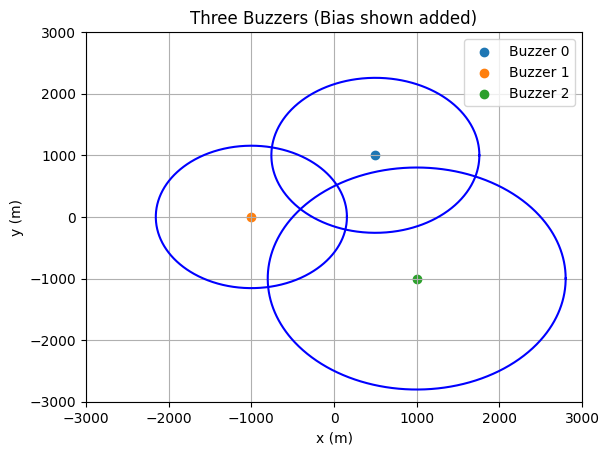

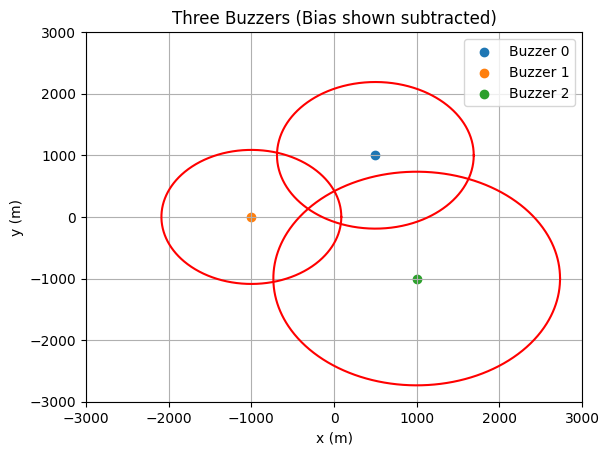

In [83]:
plot_buzzers([buzzer_1, buzzer_2, buzzer_3], "Three Buzzers (Bias shown added)", range_type="outer")
plot_buzzers([buzzer_1, buzzer_2, buzzer_3], "Three Buzzers (Bias shown subtracted)", range_type="inner")

### 3.7 [3 points]
Based on the result you got in problem 3.6, do you think the true clock bias $t_b$ is greater than, smaller than, or equivalent to $t_b$ =0.1 s? Explain the reason.

Assume other parameters are fixed and correct ($t^{(1)}$ =0.5 s, $t^{(2)}$ =1.5 s, $t^{(3)}$ =0.0 s, $t_u^{(1)}$ = 4.1 s, $t_u^{(2)}$ = 4.8 s, and $t_u^{(3)}$ = 5.2 s)

***ANSWER***

The clock bias is likely larger than 0.1 seconds because the three inner and outer bounds of the pseudorange for the satellites do not intersect at all. A larger bias will mean more "area" in which the regions will be able to intersect.

### 3.8 [4 points]
For three different clock biases: $t_b$ = +0.06 s, $t_b$ =+0.56 s, and $t_b$ =+1.06 s, plot the three geometries that satisfy each equation of the buzzer measurements, along with the location of the 3 buzzers. Assume other parameters are fixed and correct ($t^{(1)}$ =0.5 s, $t^{(2)}$ =1.5 s, $t^{(3)}$ =0.0 s, $t_u^{(1)}$ = 4.1 s, $t_u^{(2)}$ = 4.8 s, and $t_u^{(3)}$ = 5.2 s).

Which clock bias do you think is closest to the correct clock bias? Does the result match with your answer at problem 3.7?

***ANSWER***

In [84]:
def plot_with_bias(bias):

  buzzer_1 = get_buzzer(500, 1000, t_1, bias, t_u_1)
  buzzer_2 = get_buzzer(-1000, 0, t_2, bias, t_u_2)
  buzzer_3 = get_buzzer(1000, -1000, t_3, bias, t_u_3)

  plot_buzzers([buzzer_1, buzzer_2, buzzer_3], f"Bias of {bias}s ($+t_b$)", "outer")
  plot_buzzers([buzzer_1, buzzer_2, buzzer_3], f"Bias of {bias}s ($-t_b$)", "inner")


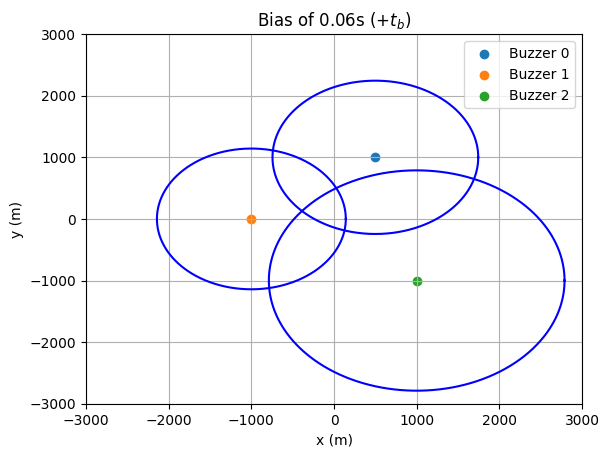

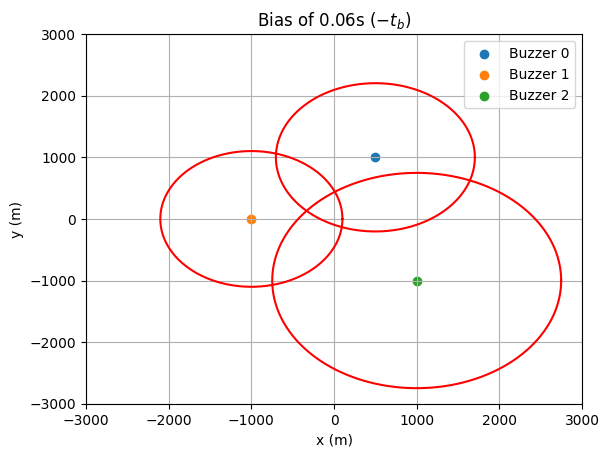

In [85]:
plot_with_bias(0.06)

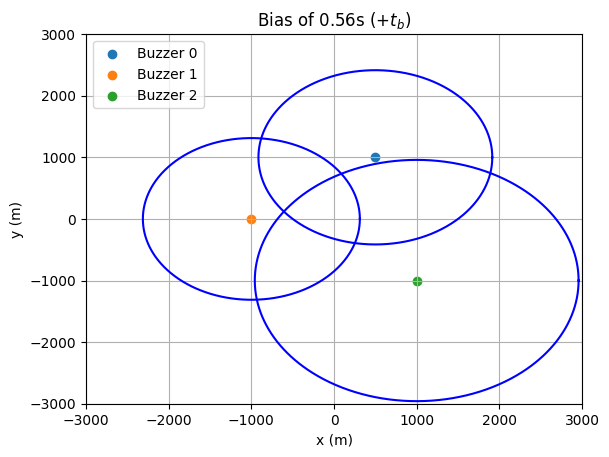

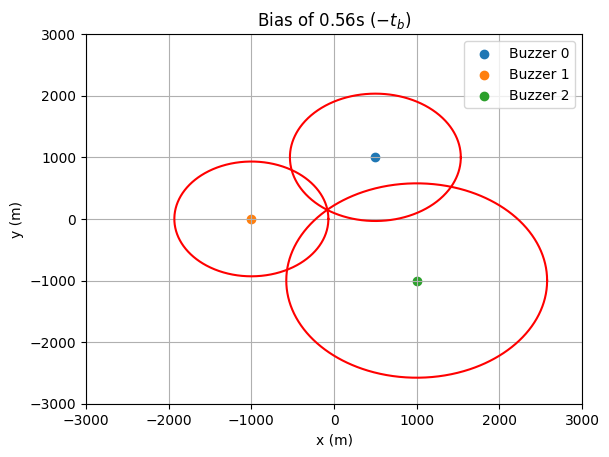

In [86]:
plot_with_bias(0.56)

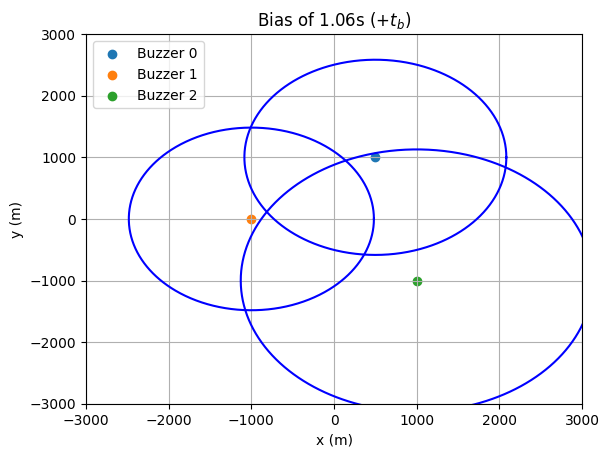

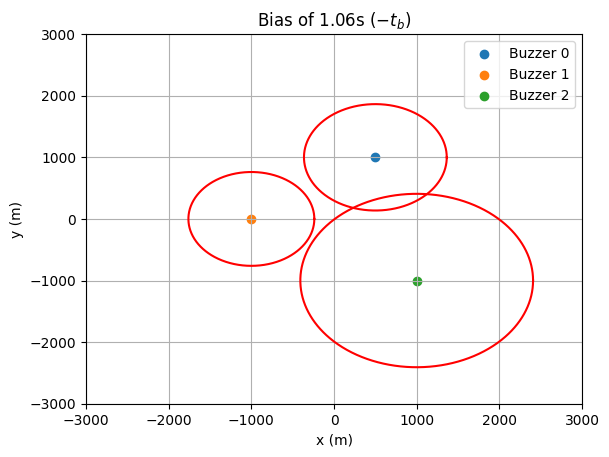

In [87]:
plot_with_bias(1.06)

I think (or would like to think) 0.56 is the likely clock bias because when the bias is subtracted (as signified by the plot in red), the 3 buzzers just barely intersect.

**Note**
You will learn how to solve these set of equations (for the 3d + clock bias case) in Lecture 3.


### 3.9 Bonus [2 points]

Suppose you have a fourth buzzer. However, this fourth buzzers are equipped with cheaper clocks, and sometimes it sends out a biased transmission time.

Using the measurement from the four buzzers, can you think of a way to tell if the forth buzzer is sending out the correct transmission time?

You can assume the other three buzzers are sending out the correct transmission time, and we know the true exact position of the fourth buzzer.

***ANSWER***

You would solve the problem with the previous 3 buzzers, then get the pseudorange of the 4th buzzer, and if it intersects at the same point, then the 4th buzzer clock is correct.